# DAAAnalyzer_4.0_BatchAnalysis.ipynb
Created by: JFranco | Created On: 20 JAN 2024 | Last Env: QISHA | Last Run Date: 20 JAN 2025

This Python notebook compiles the DPOAE and ABR Thresholds, and Wave I amplitudes from multiple DAA Runs

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters for plotting
conditions = ["Pink","Blue","NonInj"]
pltOrder = conditions
colors = {pltOrder[0]:'mediumorchid',pltOrder[1]:'slateblue', pltOrder[2]:'black'}
legColors = ["mediumorchid","slateblue",'black']

In [3]:
# *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
batchID = 'AAVHABclw_CMI_NIHL_2025'
prepIDs = ['CMI_008','CMI_009', 'CMI_010']
daaRun = '3'           # For calculating batch info for a specific run
daaRuns = ['1','3']        # For calculating a threshold shift between runs
daaType = '2W Post Noise Exposure'
daaTypes = ['Baseline','2W Post Noise Exposure']

# Directories 
#   - Existing ones - 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/DAA/'
dirBatch = dirMain+'BatchAnalysis/'+batchID+'/'
#dirPrep = dirMain+prepID+'/'
#dirData = dirPrep+'RawData/'
#dirMD = dirPrep+'Metadata/'
#dirSV = dirPrep+'Results/'
#dirDFs = dirSV+"1_CompiledMeasurements/"
#dirSjABRPlts = dirSV+"3_ABRPlotsBySubject/"
#dirGpABRPlts = dirSV+"4_ABRPlotsByGroup/"
#dirSjWOPlts = dirSV+"5_Wave1PlotsBySubject/"
#dirGpWOPlts = dirSV+"6_Wave1PlotsByGroup/"

#   - Ones that need to be made -
dirSV = dirBatch+'Results/'
dirDFs = dirSV+"1_CompiledMeasurements/"
dirPltDP = dirSV+"2_PlotsDPOAEs/"
dirPltABR = dirSV+"3_PlotsABRs/"
dirPltWO = dirSV+"4_PlotsWaveOne/"
dirPltTS = dirSV+"5_PlotsThsShifts/"

# Filenames
#    - Existing ones -
#fnMD = prepID+'.Metadata.AnimalInfo.csv'
fnBaseDPs = '.DPOAEf2Thresholds.DAA_'
fnBaseABRs = '.ABRThresholds.DAA_'

#    - Ones that will be made - 
fnThsDP = batchID+'.DPOAEThresholds.DAA_'+daaRun+'.csv'
fnThsABR = batchID+'.DPOAEThresholds.DAA_'+daaRun+'.csv'

# Filenames
#    - Existing ones -
#fnMD = prepID+'.Metadata.AnimalInfo.csv'
#fnThs = prepID+'.ABRThresholds.DAA_'+daaRun+'.csv'

#    - Ones that will be made - 
#fnABRVals = prepID+'.AllABRVals.DAA_'+daaRun+'.csv'
#fnGBABRs = prepID+'.GroupABRStats.DAA_'+daaRun+'.csv'
#fnPltPF = prepID+'.ABR.DAA_'+daaRun

In [4]:
#      *** MAKE SUBFOLDERS AS NECESSARY**
# Create directory for storing spreadsheets and summary plots if they don't exist
if not os.path.exists(dirSV): os.mkdir(dirSV)
if not os.path.exists(dirDFs): os.mkdir(dirDFs)
if not os.path.exists(dirPltDP): os.mkdir(dirPltDP)
if not os.path.exists(dirPltABR): os.mkdir(dirPltABR)
if not os.path.exists(dirPltWO): os.mkdir(dirPltWO)
if not os.path.exists(dirPltTS): os.mkdir(dirPltTS)

In [5]:
#    *** LOAD THRESHOLD SHEETS **
dfDPThs = pd.DataFrame()
dfABRThs = pd.DataFrame()
for prepID in prepIDs:
    dir = dirMain+prepID+'/Results/1_CompiledMeasurements/'
    dfDP = pd.read_csv(dir+prepID+fnBaseDPs+str(daaRun)+'.csv')
    dfABR = pd.read_csv(dir+prepID+fnBaseABRs+str(daaRun)+'.csv')
    dfDPThs = pd.concat([dfDPThs, dfDP])
    dfABRThs = pd.concat([dfABRThs, dfABR])
dfDPThs.drop(['Unnamed: 0'], axis=1, inplace=True)
dfABRThs.drop(['Unnamed: 0','index'], axis=1, inplace=True)

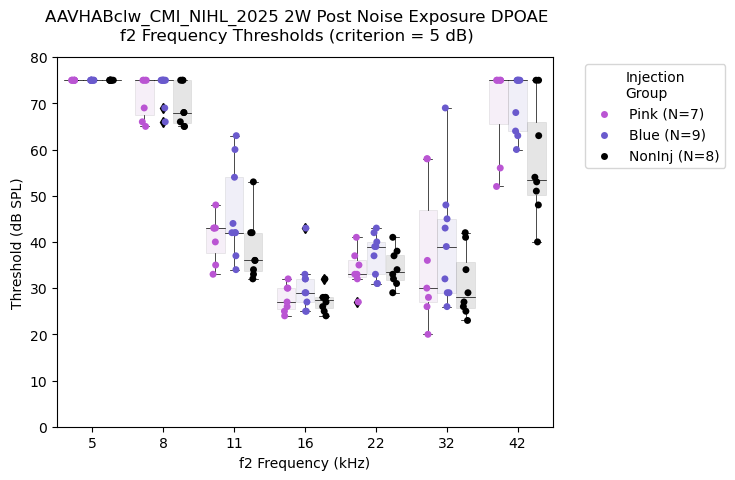

In [6]:
# *** PLOT DPOAE f2 THRESHOLDS ***
plot = "DPOAEf2Thresholds.DAA_"+daaRun
plottype = "BoxSwarm"
title = batchID+" "+daaType+" DPOAE\n"+"f2 Frequency Thresholds (criterion = 5 dB)"
hue = 'InjGroup'
x = "f2Freq_kHz"
y="Thresh_dBSPL"
xlab = "f2 Frequency (kHz)"
ylab = "Threshold (dB SPL)"
ymin = 0
ymax = 80

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

#fig= plt.figure(figsize=(4,3))
#plt.subplots_adjust(top = 0.8, bottom=0.04, hspace=.3, wspace=.2)
#fig.suptitle(title)
# Code for two styles of plots are shown below 
# Uncomment code below for an alternate plot style (i.e., points connected by a line at average with errorbars)
#ax = sns.lineplot(data=dfDPs,x=x, y=y, hue=hue,palette=colors)
#ax = sns.pointplot(data=dfDPs,x=x, y=y, hue=hue,markers=["o","s","^"], linestyles=["-", "-","-"],
#                   errorbar='sd', capsize=.2, palette=colors)
ax1 = sns.stripplot(data=dfDPThs,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=dfDPThs,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(dfABRThs[dfABRThs['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])

plt.legend(title='Injection\nGroup', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])

plt.savefig(dirPltDP+batchID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')

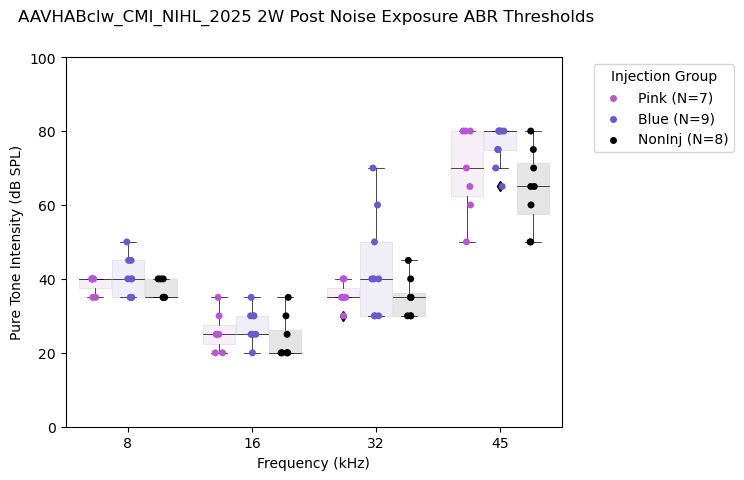

In [7]:
# *** PLOT ABR THRESHOLDS ***
plot = "ABRThresholds.DAA_"+daaRun
plottype = "BoxSwarm"
title = batchID+" "+daaType+" ABR Thresholds"
hue = 'InjGroup'
x = "Freq_kHz"
y="Th_dB_Blinded"
xlab = "Frequency (kHz)"
ylab ="Pure Tone Intensity (dB SPL)"
ymin = 0
ymax = 100

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

#fig= plt.figure(figsize=(4,3))
#plt.subplots_adjust(top = 0.8, bottom=0.04, hspace=.3, wspace=.2)
#fig.suptitle(title)
# Code for two styles of plots are shown below 
# Uncomment code below for an alternate plot style (i.e., points connected by a line at average with errorbars)
#ax = sns.lineplot(data=dfDPs,x=x, y=y, hue=hue,palette=colors)
#ax = sns.pointplot(data=dfDPs,x=x, y=y, hue=hue,markers=["o","s","^"], linestyles=["-", "-","-"],
#                   errorbar='sd', capsize=.2, palette=colors)
ax1 = sns.stripplot(data=dfABRThs,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=dfABRThs,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(dfABRThs[dfABRThs['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(dirPltABR+batchID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')

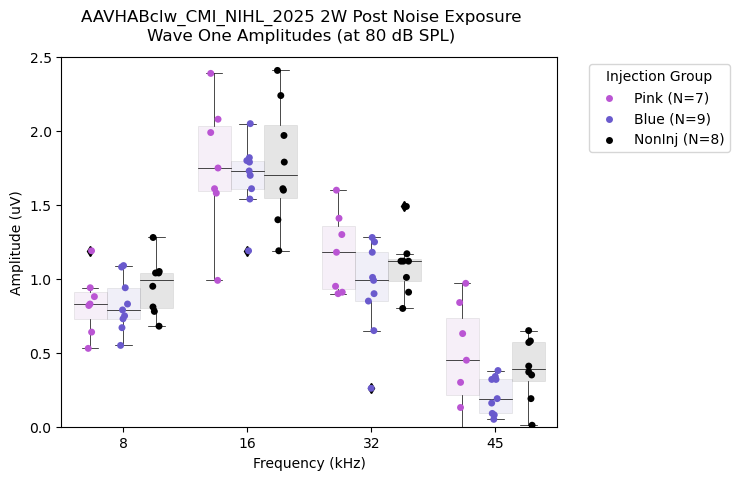

In [8]:
# *** PLOT WAVE ONE AMPLITUDES ***
plot = "WaveOneAmplitudes.DAA_"+daaRun
plottype = "BoxSwarm"
title = batchID+" "+daaType+"\nWave One Amplitudes (at 80 dB SPL)"
hue = 'InjGroup'
x = "Freq_kHz"
y="W1uV_80dB"
xlab = "Frequency (kHz)"
ylab ="Amplitude (uV)"
ymin = 0
ymax = 2.5

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

#fig= plt.figure(figsize=(4,3))
#plt.subplots_adjust(top = 0.8, bottom=0.04, hspace=.3, wspace=.2)
#fig.suptitle(title)
# Code for two styles of plots are shown below 
# Uncomment code below for an alternate plot style (i.e., points connected by a line at average with errorbars)
#ax = sns.lineplot(data=dfDPs,x=x, y=y, hue=hue,palette=colors)
#ax = sns.pointplot(data=dfDPs,x=x, y=y, hue=hue,markers=["o","s","^"], linestyles=["-", "-","-"],
#                   errorbar='sd', capsize=.2, palette=colors)
ax1 = sns.stripplot(data=dfABRThs,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=dfABRThs,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(dfABRThs[dfABRThs['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(dirPltABR+batchID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')